In [2]:
import pandas as pd
sales = pd.read_csv('../data/sales.csv')

In [8]:
country_sales = (
    sales.groupby('Country')
    .agg
    (
        Revenue = ("Revenue",'sum'),
        Orders= ('Invoice','nunique'),
        Units= ('Quantity','sum'),
        Customers = ('Customer ID','nunique')
    )
    .reset_index()
)

country_sales['AOV'] = country_sales['Revenue'] / country_sales['Orders']

## sort by revenue
country_sales = country_sales.sort_values(
    "Revenue",
    ascending=False
)


print("Country Sales Analysis:")
print(country_sales)

Country Sales Analysis:
                 Country      Revenue  Orders    Units  Customers          AOV
37        United Kingdom  8812311.833   20439  4881837       3971   431.151809
10                  EIRE   380909.570     348   193048          5  1094.567730
24           Netherlands   268784.350     135   183679         22  1990.995185
13               Germany   202025.391     347   108633         67   582.205738
12                France   147103.140     241   163029         47   610.386473
32                Sweden    53501.990      69    52555         16   775.391159
9                Denmark    50906.850      26   229690          9  1957.955769
31                 Spain    47568.650      66    22841         25   720.737121
33           Switzerland    43921.390      40    22255         14  1098.034750
0              Australia    31446.800      40    20189         15   786.170000
7        Channel Islands    24546.320      30    11991         11   818.210667
3                Belgium    

In [6]:
top_countries = country_sales.head(10)
print("Top 10 Countries by Revenue:")
print(top_countries)

Top 10 Countries by Revenue:
           Country      Revenue  Orders    Units  Customers          AOV
37  United Kingdom  8812311.833   20439  4881837       3971   431.151809
10            EIRE   380909.570     348   193048          5  1094.567730
24     Netherlands   268784.350     135   183679         22  1990.995185
13         Germany   202025.391     347   108633         67   582.205738
12          France   147103.140     241   163029         47   610.386473
32          Sweden    53501.990      69    52555         16   775.391159
9          Denmark    50906.850      26   229690          9  1957.955769
31           Spain    47568.650      66    22841         25   720.737121
33     Switzerland    43921.390      40    22255         14  1098.034750
0        Australia    31446.800      40    20189         15   786.170000


In [9]:
total_revenue = country_sales["Revenue"].sum()

uk_revenue = country_sales.loc[
    country_sales["Country"] == "United Kingdom",
    "Revenue"
].iloc[0]

uk_percentage = (
    uk_revenue / total_revenue * 100
)

print("Total Revenue:", total_revenue)

print("UK Revenue:", uk_revenue)

print("UK Revenue Contribution:", uk_percentage, "%")

Total Revenue: 10271762.664
UK Revenue: 8812311.833
UK Revenue Contribution: 85.79162234623064 %


In [10]:
international_revenue = (
    total_revenue - uk_revenue
)

international_percentage = (
    international_revenue / total_revenue * 100
)

print("International Revenue:", international_revenue)

print(
    "International Revenue Contribution:",
    international_percentage,
    "%"
)

International Revenue: 1459450.8310000002
International Revenue Contribution: 14.208377653769357 %


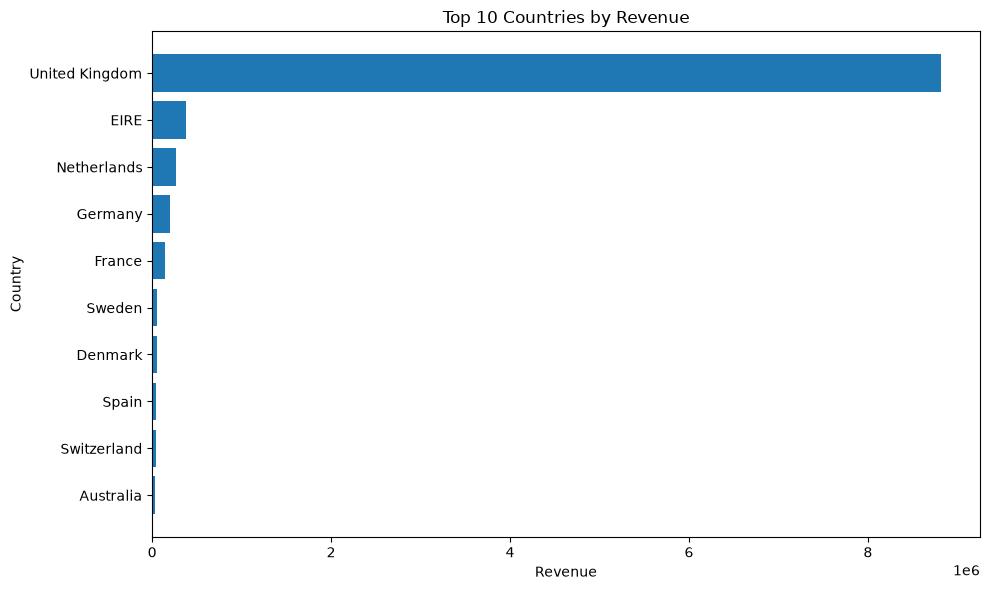

In [11]:
import matplotlib.pyplot as plt


top_10 = (
    country_sales
    .head(10)
    .sort_values("Revenue")
)


plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Country"],
    top_10["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [12]:
country_sales["Revenue_per_Customer"] = (
    country_sales["Revenue"] /
    country_sales["Customers"]
)

print(
    country_sales[
        [
            "Country",
            "Revenue",
            "Customers",
            "Revenue_per_Customer"
        ]
    ].head(15)
)

            Country      Revenue  Customers  Revenue_per_Customer
37   United Kingdom  8812311.833       3971           2219.166918
10             EIRE   380909.570          5          76181.914000
24      Netherlands   268784.350         22          12217.470455
13          Germany   202025.391         67           3015.304343
12           France   147103.140         47           3129.854043
32           Sweden    53501.990         16           3343.874375
9           Denmark    50906.850          9           5656.316667
31            Spain    47568.650         25           1902.746000
33      Switzerland    43921.390         14           3137.242143
0         Australia    31446.800         15           2096.453333
7   Channel Islands    24546.320         11           2231.483636
3           Belgium    24537.580         17           1443.387059
28         Portugal    24265.000         18           1348.055556
26           Norway    23944.180          5           4788.836000
18        